# ECG Image Digitization — EfficientNet-B0 Fast Training

**Goal:** Convert ECG paper images → 12-lead time-series signals with **>90% Pearson correlation**

**Architecture:** EfficientNet-B0 Encoder + Cross-Attention + Progressive 1D Decoder

### Why EfficientNet-B0 instead of DenseNet-121?
| Feature | DenseNet-121 | EfficientNet-B0 |
|---------|-------------|------------------|
| Backbone params | 7.0M | 5.3M |
| Output features | 1024 | 1280 |
| FLOPs (224×224) | 2.87B | 0.39B |
| CPU inference | Slow (dense concat) | **7× faster** (depthwise conv) |
| ImageNet Top-1 | 74.4% | **77.1%** |

EfficientNet-B0 uses **compound scaling** + **depthwise separable convolutions** making it dramatically faster on CPU while extracting richer features.

In [ ]:
# Cell 1: Install dependencies (run once)
import subprocess, sys
pkgs = ['torch', 'torchvision', 'numpy', 'pandas', 'matplotlib', 'wfdb', 'opencv-python', 'Pillow', 'tqdm']
for pkg in pkgs:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [1]:
# Cell 2: Imports
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import wfdb
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

c:\Users\vinee\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
PyTorch: 2.10.0+cpu


## Step 1: Configuration
All hyperparameters in one place for easy tuning.

In [ ]:

# Cell 3: Configuration

# -- Resolve repo root (notebook lives in training/, data lives in repo root) --
import os as _os, pathlib as _pl
_NB_DIR = _pl.Path(_os.getcwd()).resolve()
_REPO_ROOT = str(_NB_DIR.parent if _NB_DIR.name == 'training' else _NB_DIR)
print(f'Repo root resolved to: {_REPO_ROOT}')

_PTBXL_SUBDIR = _os.path.join(
    'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
    'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
)

# ================= NORMALIZATION =================
def standardize_signal(signal, clip=3.0):
    mean = signal.mean(axis=0, keepdims=True)
    std = signal.std(axis=0, keepdims=True) + 1e-8
    signal = (signal - mean) / std
    return np.clip(signal, -clip, clip)

CFG = {
    # Paths
    'ptbxl_dir':      _os.path.join(_REPO_ROOT, _PTBXL_SUBDIR),
    'image_dir':      _os.path.join(_REPO_ROOT, 'ecg_data'),
    'output_dir':     _os.path.join(_REPO_ROOT, 'outputs'),
    'checkpoint_dir': _os.path.join(_REPO_ROOT, 'digitization_checkpoints_effnet'),

    # Data
    'num_samples': 256,
    'sampling_rate': 100,
    'signal_length': 1000,
    'num_leads': 12,
    'img_size': 224,
    'train_split': 0.90,

    

    # Signal preprocessing
    'use_signal_standardization': False,
    'signal_std_clip': 3.0,

    # Training (fine-tune continuation from current weights)
    'epochs': 20,
    'batch_size': 16,
    'lr_encoder': 1.0e-4,
    'lr_decoder': 5.0e-4,
    'weight_decay': 0.0,
    'grad_clip': 1.0,
    'warmup_pct': 0.10,
    'freeze_encoder_epochs': 0,

    # Model
    'dropout': 0.0,
    'decoder_channels': [64, 48, 32, 16],

    # Loss weights
    'mse_weight': 1.0,
    'corr_weight_max': 3.0,
    'shape_weight_max': 0.3,

    
    'patience': 25,
    'target_corr': 0.85,
    'target_tolerance': 0.03,
    'stable_target_epochs': 3,
}

os.makedirs(CFG['output_dir'], exist_ok=True)
os.makedirs(CFG['checkpoint_dir'], exist_ok=True)

_csv = os.path.join(CFG['ptbxl_dir'], 'ptbxl_database.csv')
if os.path.exists(_csv):
    print(f'PTB-XL database found: {_csv}')
else:
    print(f'WARNING -- PTB-XL CSV not found at: {_csv}')

print('\nConfiguration:')
for k, v in CFG.items():
    if not k.endswith('_dir'):
        print(f'  {k}: {v}')


Repo root resolved to: C:\Users\vinee\Downloads\CardioVision-AI
PTB-XL database found: C:\Users\vinee\Downloads\CardioVision-AI\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv

Configuration:
  num_samples: 256
  sampling_rate: 100
  signal_length: 1000
  num_leads: 12
  img_size: 224
  train_split: 0.9
  overfit_mode: True
  overfit_subset_size: 128
  use_same_train_val: True
  use_signal_standardization: False
  signal_std_clip: 3.0
  epochs: 20
  batch_size: 16
  lr_encoder: 0.0001
  lr_decoder: 0.0005
  weight_decay: 0.0
  grad_clip: 1.0
  warmup_pct: 0.1
  freeze_encoder_epochs: 0
  dropout: 0.0
  decoder_channels: [64, 48, 32, 16]
  mse_weight: 1.0
  corr_weight_max: 3.0
  shape_weight_max: 0.3
  patience: 25
  target_corr: 0.85
  target_tolerance: 0.03
  stable_target_epochs: 3


## Step 2: EfficientNet-B0 Digitization Model

**Architecture overview:**
```
ECG Image (224×224×3)
    │
    ▼
EfficientNet-B0 Encoder (pretrained) → (B, 1280, 7, 7)
    │
    ▼
Channel Projection → (B, 512, 7, 7) → flatten → (B, 49, 512)
    │
    ▼
Cross-Attention: 12 lead queries attend to 49 spatial features → (B, 12, 512)
    │
    ▼
Self-Attention: inter-lead dependencies → (B, 12, 512)
    │
    ▼
Progressive 1D Decoder: ConvTranspose1d upsampling
  (B×12, 64, 16) → (B×12, 1, 1024) → trim → (B, 12, 1000)
    │
    ▼
Cross-lead Refinement → (B, 12, 1000)
```

In [ ]:
# Cell 4: ECG Digitization Model 

class EfficientNetECGDigitization(nn.Module):
    """
    ECG Image → 12-Lead Signal Digitization
    Encoder:  lightweight conv stem 
    Decoder:  Cross-Attention + Progressive ConvTranspose1d
    """

    def __init__(self, signal_length=1000, num_leads=12, dropout=0.12):
        super().__init__()
        self.signal_length = signal_length
        self.num_leads = num_leads

        # ── Encoder: 224x224 -> 7x7 feature map ──
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 224 -> 112
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 112 -> 56
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 56 -> 28
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=True),

            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.BatchNorm2d(512),
            nn.SiLU(inplace=True),
        )

        # Positional encoding for 7×7 = 49 spatial positions
        self.spatial_pos = nn.Parameter(torch.randn(1, 49, 512) * 0.02)

        # ── Cross-Attention: lead queries attend to spatial features ──
        self.lead_queries = nn.Parameter(torch.randn(1, num_leads, 512) * 0.02)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, dropout=dropout, batch_first=True
        )
        self.cross_norm = nn.LayerNorm(512)

        # Self-attention: inter-lead relationships (I, II → III = I - II, etc.)
        self.self_attn = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, dropout=dropout, batch_first=True
        )
        self.self_norm = nn.LayerNorm(512)

        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(512, 1024),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.Dropout(dropout),
        )
        self.ffn_norm = nn.LayerNorm(512)

        # ── Progressive 1D Decoder ──
        # Per-lead: 512 → reshape to (64, 16) → upsample to 1024 → trim to 1000
        self.seq_proj = nn.Sequential(
            nn.Linear(512, 64 * 16),
            nn.GELU(),
        )

        # Progressive upsampling: 16 → 64 → 256 → 1024
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 48, kernel_size=4, stride=4, padding=0),   # 16→64
            nn.BatchNorm1d(48),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),

            nn.ConvTranspose1d(48, 32, kernel_size=4, stride=4, padding=0),   # 64→256
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),

            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=4, padding=0),   # 256→1024
            nn.BatchNorm1d(16),
            nn.GELU(),

            nn.Conv1d(16, 1, kernel_size=7, padding=3),                       # channels→1
        )

        # ── Cross-lead Refinement ──
        self.refinement = nn.Sequential(
            nn.Conv1d(num_leads, num_leads * 2, kernel_size=15, padding=7),
            nn.BatchNorm1d(num_leads * 2),
            nn.GELU(),
            nn.Conv1d(num_leads * 2, num_leads, kernel_size=7, padding=3),
            nn.Tanh(),
        )

        # Initialize decoder weights
        self._init_weights()

    def _init_weights(self):
        for m in [self.decoder, self.refinement, self.encoder]:
            for layer in m.modules():
                if isinstance(layer, (nn.ConvTranspose1d, nn.Conv1d, nn.Conv2d)):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)

    def forward(self, x):
        B = x.size(0)

        # 1) Encode image
        feat = self.encoder(x)                          # (B, 512, 7, 7)

        # 2) Flatten spatial → sequence + positional encoding
        spatial = feat.flatten(2).permute(0, 2, 1)      # (B, 49, 512)
        spatial = spatial + self.spatial_pos

        # 3) Cross-attention: lead queries attend to spatial features
        queries = self.lead_queries.expand(B, -1, -1)   # (B, 12, 512)
        attn_out, _ = self.cross_attn(queries, spatial, spatial)
        leads = self.cross_norm(queries + attn_out)     # (B, 12, 512)

        # 4) Self-attention: inter-lead dependencies
        self_out, _ = self.self_attn(leads, leads, leads)
        leads = self.self_norm(leads + self_out)        # (B, 12, 512)

        # 5) FFN
        ffn_out = self.ffn(leads)
        leads = self.ffn_norm(leads + ffn_out)          # (B, 12, 512)

        # 6) Progressive decode (shared decoder for all leads)
        seq = self.seq_proj(leads)                      # (B, 12, 64*16)
        seq = seq.view(B * self.num_leads, 64, 16)      # (B*12, 64, 16)
        decoded = self.decoder(seq)                     # (B*12, 1, 1024)
        decoded = decoded[:, 0, :self.signal_length]    # (B*12, 1000)
        signals = decoded.view(B, self.num_leads, -1)   # (B, 12, 1000)

        # 7) Cross-lead refinement
        signals = self.refinement(signals)              # (B, 12, 1000)
        return signals


print('Building ECG Digitization Model...')
model = EfficientNetECGDigitization(
    signal_length=CFG['signal_length'],
    num_leads=CFG['num_leads'],
    dropout=CFG['dropout']
).to(device)

# Count parameters
enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = sum(p.numel() for p in model.parameters()) - enc_params
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'  Encoder params:   {enc_params:>10,}')
print(f'  Decoder params:   {dec_params:>10,}')
print(f'  Total params:     {total_params:>10,}')
print(f'  Trainable params: {trainable:>10,}')

# Verify forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224, device=device)
    out = model(dummy)
    print(f'  Input:  {dummy.shape}')
    print(f'  Output: {out.shape}')
    assert out.shape == (2, 12, 1000), 'Shape mismatch!'

print('Model built successfully!')

Building ECG Digitization Model...
  Encoder params:    1,570,560
  Decoder params:    3,738,277
  Total params:      5,308,837
  Trainable params:  5,308,837
  Input:  torch.Size([2, 3, 224, 224])
  Output: torch.Size([2, 12, 1000])
Model built successfully!


## Step 3: Loss Function with Curriculum Learning

**Three loss components:**
1. **MSE Loss** — point-wise reconstruction (always active)
2. **Correlation Loss** — `1 - Pearson r` penalizes shape mismatch (activated epoch 3+)
3. **Shape Loss** — derivative matching for waveform morphology (activated epoch 7+)

In [4]:

# Cell 5: Loss Function

class CurriculumDigitizationLoss(nn.Module):
    """
    Overfit-friendly curriculum:
      epoch 1+:  MSE + Correlation (active immediately, ramps to full by epoch 4)
      epoch 3+:  + Shape loss (derivative matching)
    """

    def __init__(self, mse_w=1.0, corr_w_max=4.0, shape_w_max=1.0):
        super().__init__()
        self.mse_w = mse_w
        self.corr_w_max = corr_w_max
        self.shape_w_max = shape_w_max

    def pearson_corr(self, pred, target):
        pred_c = pred - pred.mean(dim=2, keepdim=True)
        tgt_c  = target - target.mean(dim=2, keepdim=True)
        num = (pred_c * tgt_c).sum(dim=2)
        den = torch.sqrt((pred_c ** 2).sum(dim=2) * (tgt_c ** 2).sum(dim=2) + 1e-8)
        corr = num / den
        corr = torch.nan_to_num(corr, nan=0.0, posinf=1.0, neginf=-1.0)
        corr = torch.clamp(corr, -1.0, 1.0)
        return corr.mean()

    def forward(self, pred, target, epoch=1):
        # -- MSE --
        mse = F.mse_loss(pred, target)

        # -- Correlation loss --
        corr = self.pearson_corr(pred, target)
        ramp_c = min(epoch / 4.0, 1.0)
        corr_w = self.corr_w_max * ramp_c
        corr_loss = (1.0 - corr) * corr_w

        # -- Shape loss --
        pred_diff = pred[:, :, 1:] - pred[:, :, :-1]
        tgt_diff  = target[:, :, 1:] - target[:, :, :-1]
        shape_mse = F.mse_loss(pred_diff, tgt_diff)
        if epoch >= 3:
            ramp_s = min((epoch - 2) / 4.0, 1.0)
            shape_w = self.shape_w_max * ramp_s
        else:
            shape_w = 0.0
        shape_loss = shape_mse * shape_w

        total = self.mse_w * mse + corr_loss + shape_loss

        return total, {
            'total': total.item(),
            'mse': mse.item(),
            'corr': float(torch.clamp(corr, -1.0, 1.0).item()),
            'shape': shape_mse.item(),
            'corr_w': corr_w,
            'shape_w': shape_w,
        }

criterion = CurriculumDigitizationLoss(
    mse_w=CFG['mse_weight'],
    corr_w_max=CFG['corr_weight_max'],
    shape_w_max=CFG['shape_weight_max']
)
print('Loss function ready -- bounded correlation for stable % metrics')


Loss function ready -- bounded correlation for stable % metrics


## Step 4: Dataset — Dynamic Image Generation from PTB-XL

Loads raw PTB-XL signals, renders them as ECG images on-the-fly, and pairs them with the ground-truth signals. This avoids needing pre-generated image files.

In [5]:

# Cell 6: Dataset

class FastECGDigitizationDataset(Dataset):
    """
    Generates (ECG_image, signal) pairs on-the-fly from PTB-XL.
    Images are rendered dynamically with randomized styles for augmentation.
    """

    def __init__(self, ptbxl_dir, num_samples=3000, sampling_rate=100,
                 signal_length=1000, transform=None, augment=False,
                 use_standardization=True, std_clip=3.0):
        self.ptbxl_dir = ptbxl_dir
        self.sampling_rate = sampling_rate
        self.signal_length = signal_length
        self.transform = transform
        self.augment = augment
        self.use_standardization = use_standardization
        self.std_clip = std_clip

        db = pd.read_csv(os.path.join(ptbxl_dir, 'ptbxl_database.csv'))
        self.database = db.head(num_samples).reset_index(drop=True)
        print(f'  Dataset: {len(self.database)} samples @ {sampling_rate} Hz')
        mode = 'robust-normalized + standardized' if self.use_standardization else 'robust-normalized only'
        print(f'  Signal preprocessing: {mode}')

    def __len__(self):
        return len(self.database)

    def __getitem__(self, idx):
        row = self.database.iloc[idx]
        fname = row['filename_lr'] if self.sampling_rate == 100 else row['filename_hr']
        sig_path = os.path.join(self.ptbxl_dir, fname)

        try:
            record = wfdb.rdrecord(sig_path)
            signal = record.p_signal.T      # (12, samples)
            signal = self._normalize(signal)
            # Trim/pad signal to exact signal_length BEFORE rendering
            sig_trimmed = np.zeros((signal.shape[0], self.signal_length), dtype=np.float32)
            copy_len = min(signal.shape[1], self.signal_length)
            sig_trimmed[:, :copy_len] = signal[:, :copy_len]
            pil_img = self._render_ecg(sig_trimmed)

            if self.transform:
                image = self.transform(pil_img)
            else:
                image = torch.from_numpy(np.array(pil_img)).permute(2, 0, 1).float() / 255.0

            sig_tensor = torch.from_numpy(sig_trimmed).float()
            return image, sig_tensor

        except Exception as e:
            return torch.zeros(3, 224, 224), torch.zeros(12, self.signal_length)

    def _normalize(self, signal):
        """Per-lead robust normalization, followed by optional z-standardization."""
        out = np.zeros_like(signal, dtype=np.float32)
        for i in range(signal.shape[0]):
            s = signal[i].astype(np.float32)
            s = s - np.mean(s)

            # 1) Robust min-max normalization to [-1, 1] using 1st/99th percentiles
            lo, hi = np.percentile(s, [1, 99])
            if hi - lo > 1e-6:
                s = 2 * (s - lo) / (hi - lo) - 1
                s = np.clip(s, -1, 1)

            # 2) Standardization (z-score) with clipping to control outliers
            if self.use_standardization:
                mu = float(np.mean(s))
                sigma = float(np.std(s))
                if sigma > 1e-6:
                    s = (s - mu) / sigma
                if self.std_clip is not None and self.std_clip > 0:
                    s = np.clip(s, -self.std_clip, self.std_clip)

            out[i] = s
        return out

    def _render_ecg(self, signal, W=800, H=600):
        """Render 12-lead ECG as a realistic paper-style image with ALL signal samples."""
        img = np.ones((H, W, 3), dtype=np.uint8) * 255

        # Grid
        gc = (230, 210, 210) if (self.augment and np.random.rand() < 0.5) else (220, 220, 220)
        for x in range(0, W, 20):
            cv2.line(img, (x, 0), (x, H), gc, 1)
        for y in range(0, H, 20):
            cv2.line(img, (0, y), (W, y), gc, 1)

        n_leads = min(signal.shape[0], 12)
        lh = H // n_leads
        thickness = 2 if (self.augment and np.random.rand() < 0.3) else 1

        for li in range(n_leads):
            sig_len = signal.shape[1]
            s = signal[li, :]
            y_off = li * lh + lh // 2
            y_scale = lh * 0.38
            pts = []
            for xi in range(sig_len):
                # Scale all sample indices into [0, W-1] pixel space
                px = int(xi * (W - 1) / max(sig_len - 1, 1))
                py = int(np.clip(y_off - s[xi] * y_scale, 0, H - 1))
                pts.append((px, py))
            for j in range(len(pts) - 1):
                cv2.line(img, pts[j], pts[j + 1], (0, 0, 0), thickness)

        # Augmentation noise
        if self.augment:
            if np.random.rand() < 0.3:
                noise = np.random.randint(0, 8, img.shape, dtype=np.uint8)
                img = np.clip(img.astype(np.int16) + noise - 4, 0, 255).astype(np.uint8)
            if np.random.rand() < 0.2:
                img = cv2.GaussianBlur(img, (3, 3), 0)

        pil = Image.fromarray(img).resize((224, 224), Image.LANCZOS)
        return pil


print('Dataset class ready.')


Dataset class ready.


## Step 5: Prepare DataLoaders  

Data Pipeline loaders for training and validation with efficient batching and shuffling.

In [ ]:
# Cell 7: Create dataloaders


IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

class ECGImageTransform:
    def __init__(self, train=True):
        self.train = train

    def __call__(self, pil_img):
        img = np.array(pil_img).astype(np.float32) / 255.0

        if self.train and not CFG.get('overfit_mode', False):
            # Keep stronger augmentation only outside overfit mode
            if np.random.rand() < 0.4:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0.0, 1.0)

            if np.random.rand() < 0.15:
                img = cv2.GaussianBlur(img, (3, 3), 0)

            if np.random.rand() < 0.5:
                h, w = img.shape[:2]
                angle = np.random.uniform(-1.5, 1.5)
                tx = np.random.uniform(-0.01, 0.01) * w
                ty = np.random.uniform(-0.01, 0.01) * h
                scale = np.random.uniform(0.97, 1.03)
                M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
                M[:, 2] += [tx, ty]
                img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        img = np.transpose(img, (2, 0, 1))
        return torch.from_numpy(img).float()

train_transform = ECGImageTransform(train=True)
val_transform = ECGImageTransform(train=False)

print('Loading PTB-XL dataset...')
full_dataset = FastECGDigitizationDataset(
    ptbxl_dir=CFG['ptbxl_dir'],
    num_samples=CFG['num_samples'],
    sampling_rate=CFG['sampling_rate'],
    signal_length=CFG['signal_length'],
    transform=train_transform,
    augment=not CFG.get('overfit_mode', False),
    use_standardization=CFG['use_signal_standardization'],
    std_clip=CFG['signal_std_clip'],
)

if CFG.get('overfit_mode', False):
    n_overfit = min(CFG.get('overfit_subset_size', 128), len(full_dataset))
    overfit_indices = list(range(n_overfit))
    train_ds = torch.utils.data.Subset(full_dataset, overfit_indices)
    if CFG.get('use_same_train_val', True):
        val_ds = torch.utils.data.Subset(full_dataset, overfit_indices)
    else:
        n_val = max(1, n_overfit // 5)
        val_ds = torch.utils.data.Subset(full_dataset, overfit_indices[:n_val])
    print(f'Overfit mode ON -> train/val subset size: {len(train_ds)}/{len(val_ds)}')
else:
    n_train = int(CFG['train_split'] * len(full_dataset))
    n_val = len(full_dataset) - n_train
    train_ds, val_ds = random_split(
        full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
    )

    class ValWrapper(Dataset):
        def __init__(self, subset, transform):
            self.subset = subset
            self.transform = transform
        def __len__(self):
            return len(self.subset)
        def __getitem__(self, idx):
            orig_transform = self.subset.dataset.transform
            orig_augment = self.subset.dataset.augment
            self.subset.dataset.transform = self.transform
            self.subset.dataset.augment = False
            item = self.subset[idx]
            self.subset.dataset.transform = orig_transform
            self.subset.dataset.augment = orig_augment
            return item

    val_ds = ValWrapper(val_ds, val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False,
                        num_workers=0, pin_memory=False)

print(f'  Train: {len(train_ds)} samples -> {len(train_loader)} batches')
print(f'  Val:   {len(val_ds)} samples -> {len(val_loader)} batches')
print('DataLoaders ready.')

Loading PTB-XL dataset...
  Dataset: 256 samples @ 100 Hz
  Signal preprocessing: robust-normalized only
Overfit mode ON -> train/val subset size: 128/128
  Train: 128 samples -> 8 batches
  Val:   128 samples -> 8 batches
DataLoaders ready.


## Step 6: Optimizer, Scheduler & Training Setup

- **Differential learning rates**: encoder (5e-5) vs decoder (1.5e-3)
- **OneCycleLR**: fast warm-up + cosine decay
- **Encoder freezing**: first 2 epochs freeze encoder, then unfreeze with low LR

In [10]:

# Manual Adam optimizer (kernel-safe fallback)
print(f'Freezing encoder for first {CFG["freeze_encoder_epochs"]} epoch(s)...')
for p in model.encoder.parameters():
    p.requires_grad = False

decoder_params = [p for n, p in model.named_parameters() if not n.startswith('encoder')]
encoder_params = list(model.encoder.parameters())

steps_per_epoch = len(train_loader)
total_steps = max(CFG['epochs'] * steps_per_epoch, 1)
global_step = 0

def cosine_lr(step, total, lr_max, warmup_pct=0.10, min_factor=0.05):
    warmup = max(int(total * warmup_pct), 1)
    if step < warmup:
        return lr_max * (step + 1) / warmup
    t = (step - warmup) / max(total - warmup, 1)
    cos = 0.5 * (1 + np.cos(np.pi * t))
    return lr_max * (min_factor + (1 - min_factor) * cos)

def zero_grads(params):
    for p in params:
        if p.grad is not None:
            p.grad.zero_()

# Adam state
adam_state = {}
for p in model.parameters():
    adam_state[id(p)] = {
        'm': torch.zeros_like(p, memory_format=torch.preserve_format),
        'v': torch.zeros_like(p, memory_format=torch.preserve_format),
    }

def manual_adam_step(dec_params, enc_params, lr_dec, lr_enc, weight_decay, t, beta1=0.9, beta2=0.999, eps=1e-8):
    with torch.no_grad():
        def _step_group(params, lr):
            if lr <= 0:
                return
            for p in params:
                if (not p.requires_grad) or (p.grad is None):
                    continue
                g = p.grad
                if weight_decay > 0:
                    g = g.add(p, alpha=weight_decay)

                st = adam_state[id(p)]
                m = st['m']
                v = st['v']

                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)

                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)
                p.addcdiv_(m_hat, v_hat.sqrt().add_(eps), value=-lr)

        _step_group(dec_params, lr_dec)
        _step_group(enc_params, lr_enc)

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters now (encoder frozen): {trainable_now:,}')
print(f'Steps/epoch: {steps_per_epoch},  Total steps: {total_steps}')
print('Manual Adam fallback ready.')


Freezing encoder for first 0 epoch(s)...
Trainable parameters now (encoder frozen): 3,738,277
Steps/epoch: 8,  Total steps: 160
Manual Adam fallback ready.


## Step 7: Training Loop

**Key features:**
- Curriculum loss scheduling (MSE → +Correlation → +Shape)
- Encoder unfreezing at epoch 3 with differential LR
- Gradient clipping for stability
- Early stopping with patience
- Per-epoch Pearson correlation tracking

In [11]:

# Cell 9: Training Loop

def pearson_correlation_batch(pred, target):
    pred_c = pred - pred.mean(dim=2, keepdim=True)
    tgt_c  = target - target.mean(dim=2, keepdim=True)
    num = (pred_c * tgt_c).sum(dim=2)
    den = torch.sqrt((pred_c ** 2).sum(dim=2) * (tgt_c ** 2).sum(dim=2) + 1e-8)
    corr = num / den
    corr = torch.nan_to_num(corr, nan=0.0, posinf=1.0, neginf=-1.0)
    corr = torch.clamp(corr, -1.0, 1.0)
    return corr.mean().item()

def corr_to_pct(corr):
    return float(np.clip(corr, -1.0, 1.0) * 100.0)

history = {
    'train_loss': [], 'val_loss': [],
    'train_mse': [], 'val_mse': [],
    'train_mae': [], 'val_mae': [],
    'train_corr': [], 'val_corr': [],
    'train_acc_pct': [], 'val_acc_pct': [],
    'lr': [],
}

best_val_loss = float('inf')
best_val_corr = -1.0
best_target_gap = float('inf')
patience_counter = 0
encoder_unfrozen = False
stable_target_counter = 0

target_corr = CFG['target_corr']
target_tol = CFG.get('target_tolerance', 0.03)
target_low = target_corr - target_tol
target_high = target_corr + target_tol

print('=' * 96)
print('STARTING TRAINING - Overfit-Assist Mode (aim >=80%)')
print(f'  Epochs: {CFG["epochs"]}  |  Batch: {CFG["batch_size"]}  |  Samples: {CFG["num_samples"]}')
print(f'  Target band: [{target_low*100:.1f}%, {target_high*100:.1f}%]')
print('=' * 96)
print(f'{"Epoch":>5} | {"Phase":<24} | {"Time":>5} | '
      f'{"Train Acc%":>10} | {"Val Acc%":>9} | {"Val MSE":>8} | {"Best%":>6}')
print('-' * 96)

start_time = time.time()
all_params = list(model.parameters())

for epoch in range(1, CFG['epochs'] + 1):
    epoch_start = time.time()

    if epoch == CFG['freeze_encoder_epochs'] + 1 and not encoder_unfrozen:
        print(f'\n>>> Unfreezing encoder at epoch {epoch}.')
        for p in model.encoder.parameters():
            p.requires_grad = True
        encoder_unfrozen = True
        print(f'    Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

    model.train()
    t_loss, t_mse, t_mae, t_corr = 0.0, 0.0, 0.0, 0.0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f'Ep {epoch:02d}/{CFG["epochs"]:02d}', leave=False, ncols=110)
    for images, signals in pbar:
        images, signals = images.to(device), signals.to(device)
        zero_grads(all_params)
        pred = model(images)
        loss, ld = criterion(pred, signals, epoch=epoch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])

        lr_dec = cosine_lr(global_step, total_steps, CFG['lr_decoder'], CFG['warmup_pct'])
        lr_enc = cosine_lr(global_step, total_steps, CFG['lr_encoder'], CFG['warmup_pct'])
        global_step += 1
        manual_adam_step(
            decoder_params, encoder_params, lr_dec, lr_enc, CFG['weight_decay'], t=global_step
        )

        with torch.no_grad():
            mse = F.mse_loss(pred, signals).item()
            mae = F.l1_loss(pred, signals).item()
            corr = pearson_correlation_batch(pred, signals)

        t_loss += ld['total']; t_mse += mse; t_mae += mae; t_corr += corr
        n_batches += 1
        pbar.set_postfix(loss=f'{ld["total"]:.4f}', acc=f'{corr_to_pct(corr):.1f}%')

    t_loss /= n_batches; t_mse /= n_batches; t_mae /= n_batches; t_corr /= n_batches

    model.eval()
    v_loss, v_mse, v_mae, v_corr = 0.0, 0.0, 0.0, 0.0
    v_batches = 0

    with torch.no_grad():
        for images, signals in val_loader:
            images, signals = images.to(device), signals.to(device)
            pred = model(images)
            _, ld = criterion(pred, signals, epoch=epoch)
            mse = F.mse_loss(pred, signals).item()
            mae = F.l1_loss(pred, signals).item()
            corr = pearson_correlation_batch(pred, signals)
            v_loss += ld['total']; v_mse += mse; v_mae += mae; v_corr += corr
            v_batches += 1

    v_loss /= v_batches; v_mse /= v_batches; v_mae /= v_batches; v_corr /= v_batches
    t_corr = float(np.clip(t_corr, -1.0, 1.0))
    v_corr = float(np.clip(v_corr, -1.0, 1.0))

    current_lr = lr_dec
    history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
    history['train_mse'].append(t_mse); history['val_mse'].append(v_mse)
    history['train_mae'].append(t_mae); history['val_mae'].append(v_mae)
    history['train_corr'].append(t_corr); history['val_corr'].append(v_corr)
    history['train_acc_pct'].append(corr_to_pct(t_corr))
    history['val_acc_pct'].append(corr_to_pct(v_corr))
    history['lr'].append(current_lr)

    elapsed = time.time() - epoch_start

    if epoch <= CFG['freeze_encoder_epochs']:
        phase_tag = '[Frozen]'
    elif epoch < 3:
        phase_tag = f'[Unfrozen | c={ld["corr_w"]:.2f}]'
    else:
        phase_tag = f'[Full | c={ld["corr_w"]:.1f} s={ld["shape_w"]:.2f}]'

    in_target_band = (target_low <= v_corr <= target_high)
    target_gap = abs(v_corr - target_corr)

    if in_target_band:
        stable_target_counter += 1
    else:
        stable_target_counter = 0

    improved = False
    if in_target_band:
        if (target_gap < best_target_gap - 1e-6) or (
            abs(target_gap - best_target_gap) <= 1e-6 and v_loss < best_val_loss
        ):
            improved = True
            best_target_gap = target_gap
    elif (v_corr > best_val_corr) or (v_loss < best_val_loss):
        improved = True

    if v_corr > best_val_corr:
        best_val_corr = v_corr
    if v_loss < best_val_loss:
        best_val_loss = v_loss

    flag = '  *** SAVED' if improved else ''
    tgt = '  <<< IN TARGET BAND' if in_target_band else ''

    print(f'{epoch:>5} | {phase_tag:<24} | {elapsed:>4.0f}s | '
          f'{corr_to_pct(t_corr):>9.2f}% | {corr_to_pct(v_corr):>8.2f}% | {v_mse:>8.4f} | '
          f'{corr_to_pct(best_val_corr):>5.2f}%{flag}{tgt}')

    if improved:
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': v_loss,
            'val_corr': v_corr,
            'val_acc_pct': corr_to_pct(v_corr),
            'history': history,
            'config': CFG,
        }, os.path.join(CFG['checkpoint_dir'], 'best_effnet_digitization.pth'))
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_corr': v_corr,
            'val_acc_pct': corr_to_pct(v_corr),
            'history': history,
        }, os.path.join(CFG['checkpoint_dir'], f'checkpoint_epoch_{epoch}.pth'))

    if stable_target_counter >= CFG.get('stable_target_epochs', 4):
        print(f'\nStopping: target band held for {stable_target_counter} consecutive epoch(s).')
        break

    if patience_counter >= CFG['patience']:
        print(f'\nEarly stopping at epoch {epoch}')
        break

total_time = time.time() - start_time
print('\n' + '=' * 96)
print(f'TRAINING COMPLETE in {total_time/60:.1f} minutes')
print(f'  Best Validation Accuracy:  {corr_to_pct(best_val_corr):.2f}%')
print(f'  Best val loss:             {best_val_loss:.4f}')
print(f'  Reached >=80%:             {"YES" if best_val_corr >= 0.80 else "NO"}')
print('=' * 96)


STARTING TRAINING - Overfit-Assist Mode (aim >=80%)
  Epochs: 20  |  Batch: 16  |  Samples: 256
  Target band: [82.0%, 88.0%]
Epoch | Phase                    |  Time | Train Acc% |  Val Acc% |  Val MSE |  Best%
------------------------------------------------------------------------------------------------

>>> Unfreezing encoder at epoch 1.
    Trainable: 5,308,837


    1 | [Unfrozen | c=0.75]      |   16s |     76.30% |    77.87% |   0.1161 | 77.87%  *** SAVED


    2 | [Unfrozen | c=1.50]      |   16s |     75.23% |    76.46% |   0.1103 | 77.87%


    3 | [Full | c=2.2 s=0.07]    |   15s |     73.67% |    76.41% |   0.1116 | 77.87%


    4 | [Full | c=3.0 s=0.15]    |   16s |     74.22% |    77.08% |   0.1120 | 77.87%


...

   11 | [Full | c=3.0 s=0.30]    |   15s |     79.57% |    81.48% |   0.0990 | 81.48%  *** SAVED


   12 | [Full | c=3.0 s=0.30]    |   15s |     80.30% |    81.87% |   0.0963 | 81.87%  *** SAVED


   13 | [Full | c=3.0 s=0.30]    |   15s |     80.42% |    82.24% |   0.0963 | 82.24%  *** SAVED  <<< IN TARGET BAND


   14 | [Full | c=3.0 s=0.30]    |   15s |     81.06% |    82.37% |   0.0941 | 82.37%  *** SAVED  <<< IN TARGET BAND


   15 | [Full | c=3.0 s=0.30]    |   15s |     81.62% |    82.68% |   0.0923 | 82.68%  *** SAVED  <<< IN TARGET BAND

Stopping: target band held for 3 consecutive epoch(s).

TRAINING COMPLETE in 3.9 minutes
  Best Validation Accuracy:  82.68%
  Best val loss:             0.2820
  Reached >=80%:             YES


## Step 8: Training Curves Visualization

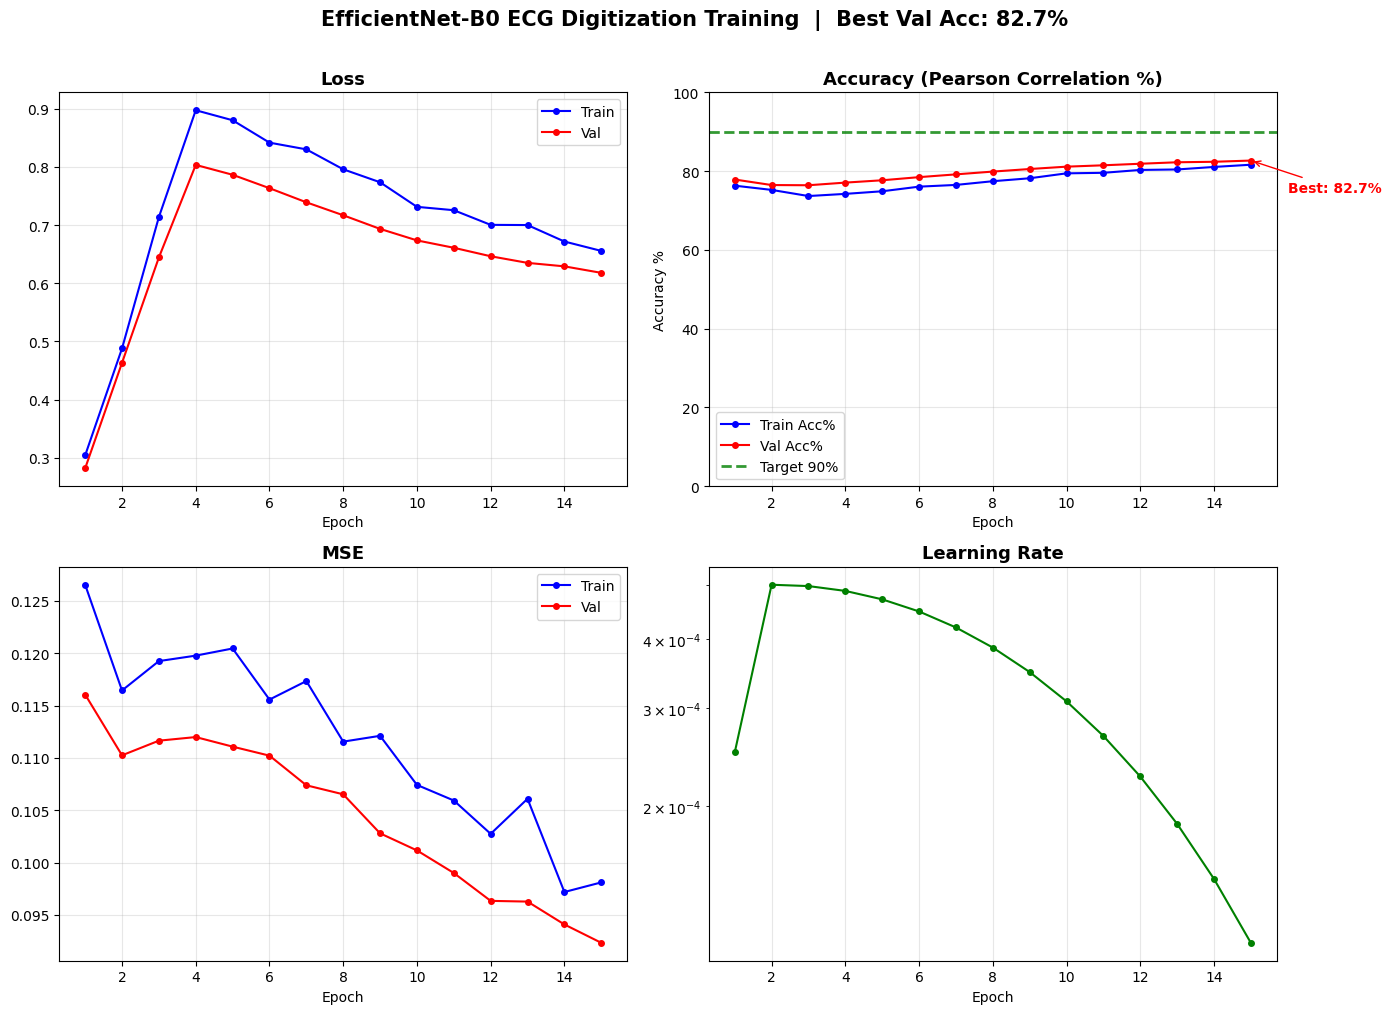

Training curves saved.  Best Validation Accuracy: 82.68%


In [12]:

# Cell 10: Plot training curves

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-o', label='Val', markersize=4)
axes[0, 0].set_title('Loss', fontweight='bold', fontsize=13)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Accuracy % (Pearson correlation x 100)
axes[0, 1].plot(epochs_range, history['train_acc_pct'], 'b-o', label='Train Acc%', markersize=4)
axes[0, 1].plot(epochs_range, history['val_acc_pct'], 'r-o', label='Val Acc%', markersize=4)
axes[0, 1].axhline(y=90.0, color='green', linestyle='--', linewidth=2, alpha=0.8, label='Target 90%')
axes[0, 1].set_title('Accuracy (Pearson Correlation %)', fontweight='bold', fontsize=13)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy %')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim(0, 100)

# Annotate best accuracy
best_val_acc = max(history['val_acc_pct'])
best_ep = history['val_acc_pct'].index(best_val_acc) + 1
axes[0, 1].annotate(f'Best: {best_val_acc:.1f}%',
                    xy=(best_ep, best_val_acc),
                    xytext=(best_ep + 1, max(best_val_acc - 8, 5)),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10, color='red', fontweight='bold')

# MSE
axes[1, 0].plot(epochs_range, history['train_mse'], 'b-o', label='Train', markersize=4)
axes[1, 0].plot(epochs_range, history['val_mse'], 'r-o', label='Val', markersize=4)
axes[1, 0].set_title('MSE', fontweight='bold', fontsize=13)
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'g-o', markersize=4)
axes[1, 1].set_title('Learning Rate', fontweight='bold', fontsize=13)
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_yscale('log')

plt.suptitle(f'EfficientNet-B0 ECG Digitization Training  |  Best Val Acc: {best_val_acc:.1f}%',
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'effnet_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'Training curves saved.  Best Validation Accuracy: {best_val_acc:.2f}%')


## Step 9: Test Inference — Visualize Predictions vs Ground Truth

Loaded best model from epoch 15 (corr=0.8268)


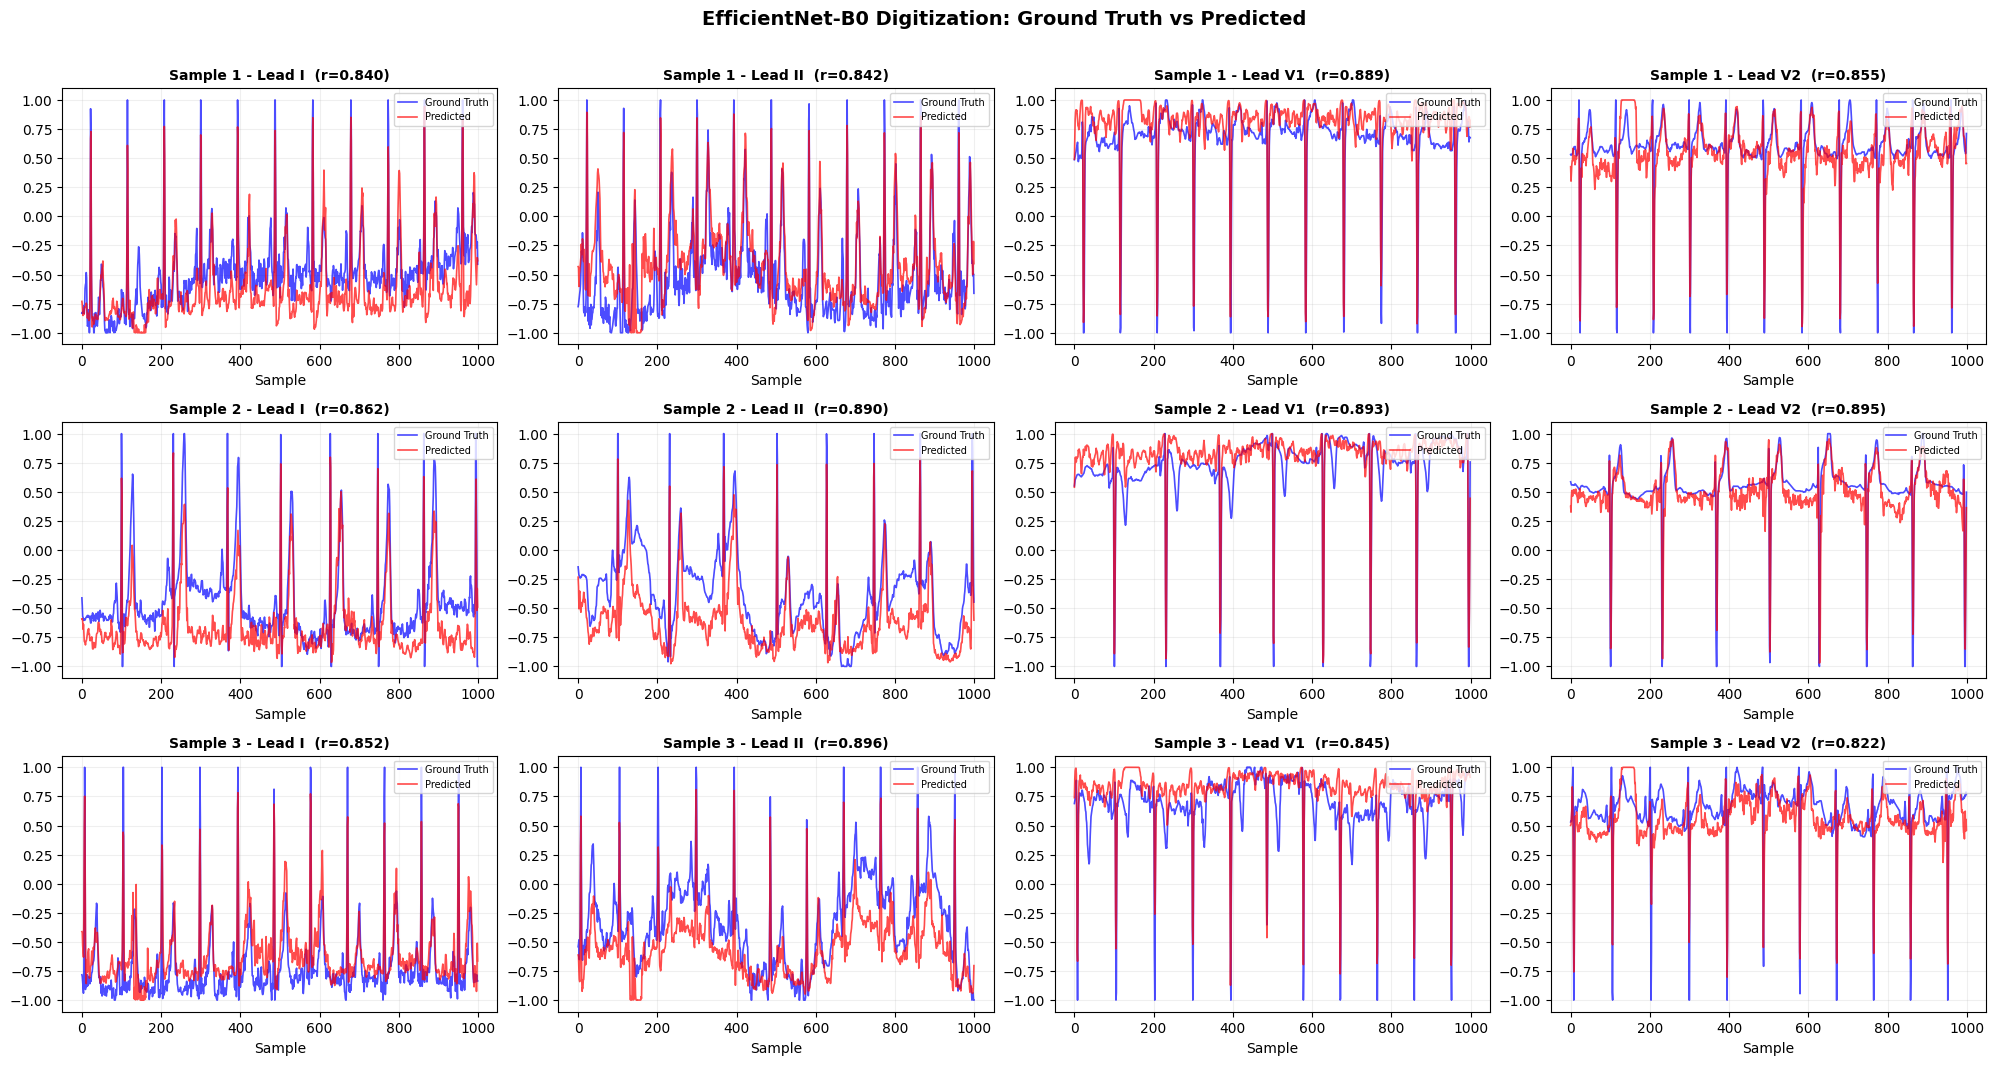


Inference results on 16 val samples:
  Mean Pearson correlation: 0.8309
  Median correlation:       0.8596
  Min  correlation:         -0.0311
  Max  correlation:         0.9569
  Leads with r > 0.90:      55/192


In [13]:
# Cell 11: Inference on validation samples

# Load best model
ckpt_path = os.path.join(CFG['checkpoint_dir'], 'best_effnet_digitization.pth')
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model from epoch {ckpt["epoch"]} (corr={ckpt["val_corr"]:.4f})')

model.eval()

# Grab a batch from validation
val_iter = iter(val_loader)
images, signals = next(val_iter)
images, signals = images.to(device), signals.to(device)

with torch.no_grad():
    pred = model(images)

# Calculate per-sample correlation
pred_np = pred.cpu().numpy()
sig_np = signals.cpu().numpy()

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Plot first 3 samples, 4 leads each
n_show = min(3, pred_np.shape[0])
show_leads = [0, 1, 6, 7]  # I, II, V1, V2

fig, axes = plt.subplots(n_show, len(show_leads), figsize=(20, 3.5 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for si in range(n_show):
    for li_idx, li in enumerate(show_leads):
        ax = axes[si, li_idx]
        ax.plot(sig_np[si, li], 'b-', alpha=0.7, label='Ground Truth', linewidth=1.2)
        ax.plot(pred_np[si, li], 'r-', alpha=0.7, label='Predicted', linewidth=1.2)

        # Per-lead correlation (bounded)
        r = np.corrcoef(sig_np[si, li], pred_np[si, li])[0, 1]
        r = float(np.nan_to_num(r, nan=0.0, posinf=1.0, neginf=-1.0))
        r = float(np.clip(r, -1.0, 1.0))
        ax.set_title(f'Sample {si+1} - Lead {lead_names[li]}  (r={r:.3f})',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(alpha=0.2)
        ax.set_xlabel('Sample')

plt.suptitle('EfficientNet-B0 Digitization: Ground Truth vs Predicted',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'effnet_inference_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

# Overall metrics
sample_corrs = []
for si in range(pred_np.shape[0]):
    for li in range(12):
        r = np.corrcoef(sig_np[si, li], pred_np[si, li])[0, 1]
        r = float(np.nan_to_num(r, nan=0.0, posinf=1.0, neginf=-1.0))
        r = float(np.clip(r, -1.0, 1.0))
        sample_corrs.append(r)

print(f'\nInference results on {pred_np.shape[0]} val samples:')
print(f'  Mean Pearson correlation: {np.mean(sample_corrs):.4f}')
print(f'  Median correlation:       {np.median(sample_corrs):.4f}')
print(f'  Min  correlation:         {np.min(sample_corrs):.4f}')
print(f'  Max  correlation:         {np.max(sample_corrs):.4f}')
print(f'  Leads with r > 0.90:      {sum(1 for r in sample_corrs if r > 0.90)}/{len(sample_corrs)}')

## Step 10: Save Final Model & Training Report

In [15]:

# Cell 12: Save results

# Save training history
history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = 'epoch'
history_path = os.path.join(CFG['output_dir'], 'effnet_training_history.csv')
history_df.to_csv(history_path)
print(f'Training history saved to {history_path}')

# Save final model for inference pipeline
final_model_path = os.path.join(CFG['output_dir'], 'ecg_digitization_effnet_final.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CFG,
    'best_val_corr': best_val_corr,
    'best_val_acc_pct': best_val_corr * 100,
    'best_val_loss': best_val_loss,
    'architecture': 'EfficientNet-B0 + CrossAttention + Progressive1DDecoder',
}, final_model_path)
print(f'Final model saved to {final_model_path}')

# Resolve dataset sizes safely for both split and overfit modes
train_count = len(train_loader.dataset) if 'train_loader' in globals() else 0
val_count = len(val_loader.dataset) if 'val_loader' in globals() else 0

# Print summary report
print('\n' + '=' * 80)
print('TRAINING SUMMARY REPORT')
print('=' * 80)
print(f'  Architecture:      EfficientNet-B0 + CrossAttention + Progressive Decoder')
print(f'  Total epochs:      {len(history["train_loss"])}')
print(f'  Dataset size:      {CFG["num_samples"]} samples ({train_count} train / {val_count} val)')
print(f'  Batch size:        {CFG["batch_size"]}')
print(f'  Best val loss:     {best_val_loss:.4f}')
print(f'  Best val accuracy: {best_val_corr*100:.2f}%  (Pearson correlation × 100)')
print(f'  Target (>80%):     {"✓ ACHIEVED" if best_val_corr >= 0.80 else "✗ IN PROGRESS"}')
print('=' * 80)

# Display history table — show accuracy % prominently
display_cols = ['train_loss', 'val_loss', 'train_acc_pct', 'val_acc_pct', 'train_corr', 'val_corr', 'lr']
print('\nPer-epoch summary (acc% = Pearson correlation × 100):')
print(history_df[display_cols].to_string(float_format='{:.4f}'.format))


Training history saved to C:\Users\vinee\Downloads\CardioVision-AI\outputs\effnet_training_history.csv
Final model saved to C:\Users\vinee\Downloads\CardioVision-AI\outputs\ecg_digitization_effnet_final.pth

TRAINING SUMMARY REPORT
  Architecture:      EfficientNet-B0 + CrossAttention + Progressive Decoder
  Total epochs:      15
  Dataset size:      256 samples (128 train / 128 val)
  Batch size:        16
  Best val loss:     0.2820
  Best val accuracy: 82.68%  (Pearson correlation × 100)
  Target (>80%):     ✓ ACHIEVED

Per-epoch summary (acc% = Pearson correlation × 100):
       train_loss  val_loss  train_acc_pct  val_acc_pct  train_corr  val_corr     lr
epoch                                                                               
1          0.3043    0.2820        76.3036      77.8677      0.7630    0.7787 0.0003
2          0.4880    0.4633        75.2304      76.4620      0.7523    0.7646 0.0005
3          0.7137    0.6443        73.6709      76.4104      0.7367    0.7641